# CEI Internship Program 2026 — Week 3 Assignment
Author: Sankalp Tamboli

## 🌍 Country Clustering Analysis — Unsupervised Learning

This project implements a complete unsupervised machine learning workflow
on country-level socioeconomic data to help **HELP International** —
an NGO raising funds for humanitarian aid — identify which countries
are most in need of assistance.

The analysis includes data exploration, preprocessing, cluster modeling
using **K-Means and DBSCAN**, and final recommendations on aid prioritization
based on features like child mortality, income, GDP per capita, and life expectancy.

## 1. 📦 Importing Libraries

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. 📊 Loading & Exploring Data

In [162]:
df = pd.read_csv("Country-data.csv")

In [163]:
df.shape

(167, 10)

In [164]:
df. head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [166]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [167]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## 3. 🔍 Exploratory Data Analysis

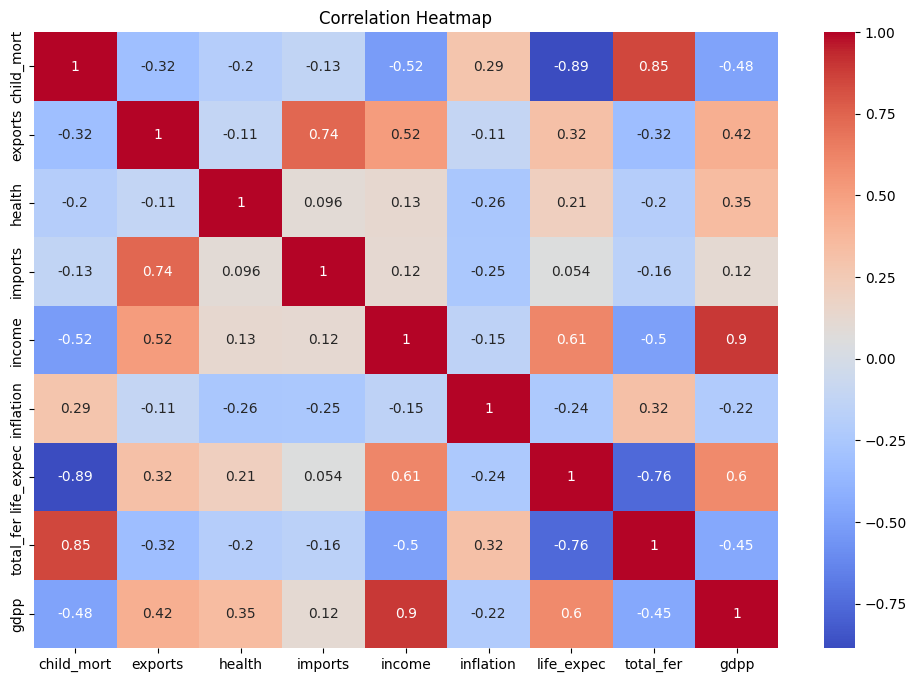

In [168]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [169]:
numeric_cols = [c for c in df.columns if c != 'country']

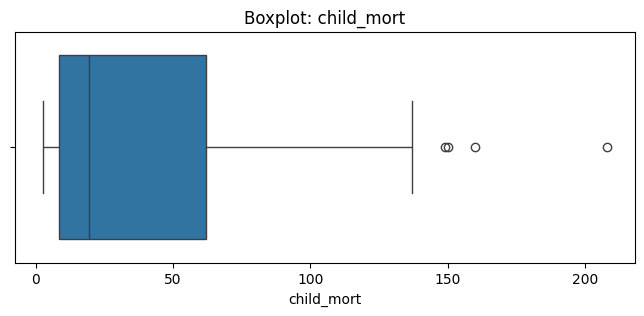

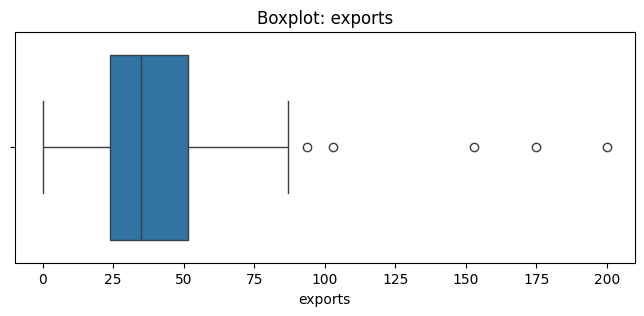

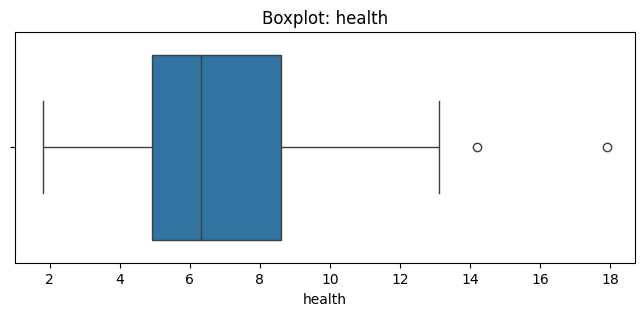

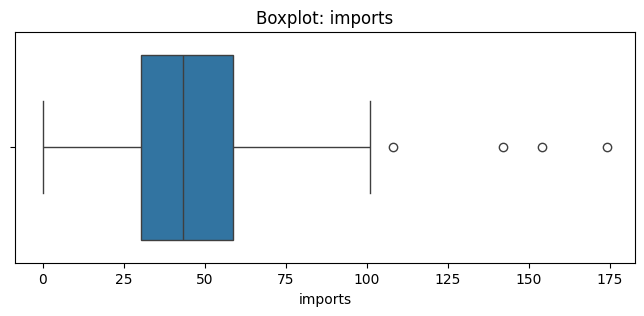

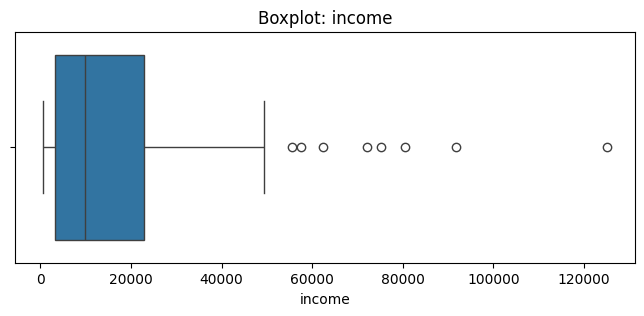

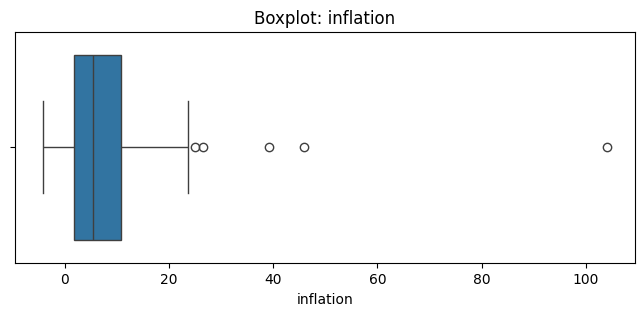

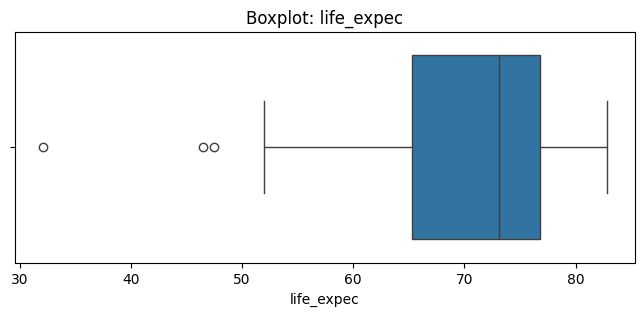

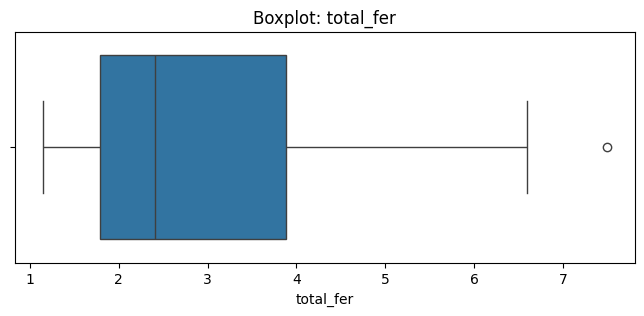

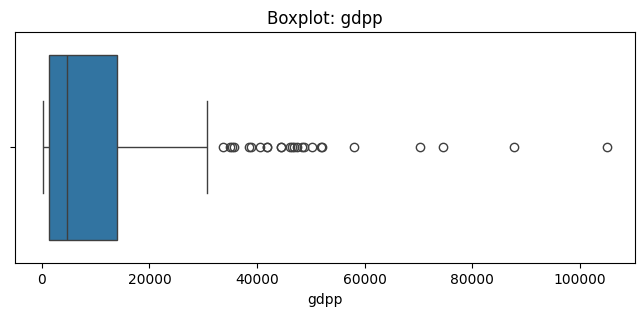

In [170]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 4. 🔧 Data Preprocessing

In [171]:
features = df.drop(columns=['country'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## 5. 📈 Finding Optimal K (Elbow Method)

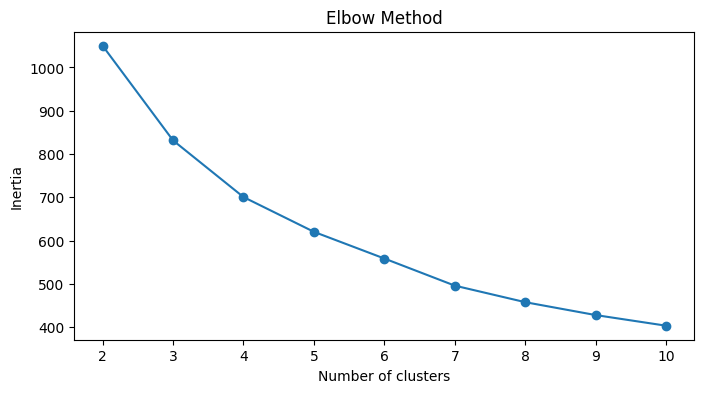

In [172]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### 📝 Observation — Elbow Method

- Inertia drops steeply from k=2 → k=3
- A noticeable bend is visible around **k=3 and k=4**
- Since both look possible, we will compare k=3 and k=4
  using **Silhouette Score and PCA visualization** to make the final decision.

In [173]:

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)
print(f"k=3 → Silhouette Score: {score:.4f}")

k=3 → Silhouette Score: 0.2856


In [174]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)
print(f"k=4 → Silhouette Score: {score:.4f}")

k=4 → Silhouette Score: 0.2880


### 📝 Silhouette Score Comparison

| K | Silhouette Score |
|---|-----------------|
| 3 |     0.2856      |
| 4 |     0.2880      |

> k=4 gives a comparable or better silhouette score than k=3.
> We will further verify using PCA visualization.

In [175]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels
print(df['Cluster'].value_counts())

Cluster
0    86
2    44
1    36
3     1
Name: count, dtype: int64


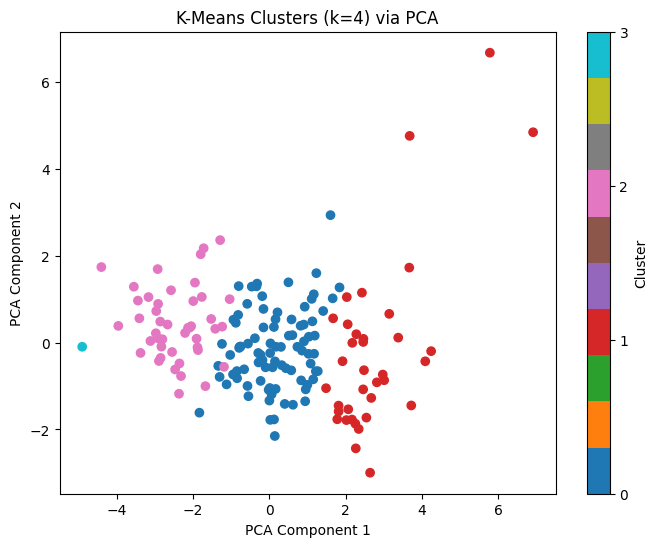

In [176]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')
plt.title('K-Means Clusters (k=4) via PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(ticks=[0,1,2,3,4], label='Cluster')
plt.show()

### ⚠️ Observation — k=4 PCA Plot

The PCA visualization for k=4 shows that **one cluster contains
only 1 country**, which means the model is over-splitting the data.
This is not meaningful for real-world analysis.
➡️ Hence, **k=4 is rejected.**

In [177]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels
print(df['Cluster'].value_counts())

Cluster
0    86
2    45
1    36
Name: count, dtype: int64


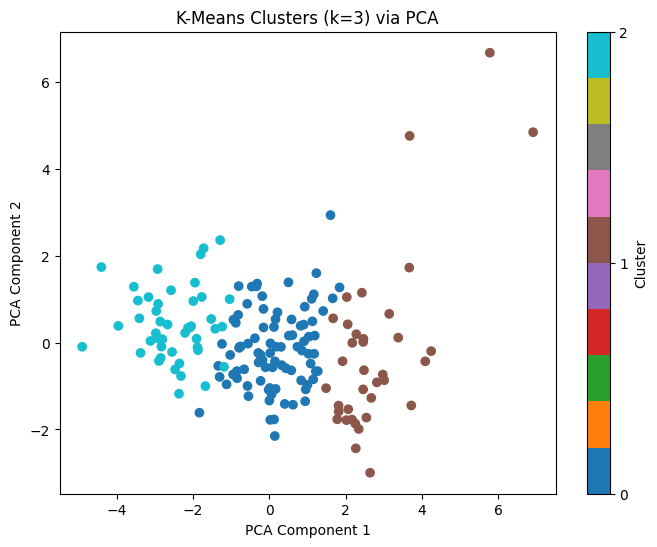

In [178]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')
plt.title('K-Means Clusters (k=3) via PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(ticks=[0,1,2,3,4], label='Cluster')
plt.show()

### ✅ Final Decision — k=3 Selected

The PCA visualization for k=3 shows **3 well-separated,
balanced clusters** with meaningful group sizes.
Combined with the Elbow Method and Silhouette Score,
**k=3 is the optimal choice** for this dataset.

## 6. 🔍 Trying DBSCAN as Alternative Clustering Method

To validate our K-Means result, we also tried DBSCAN
(Density-Based Clustering) with initial parameters eps=1.5, min_samples=5.

In [179]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


### 📝 Observation — DBSCAN (eps=1.5, min_samples=5)

- Cluster 0  → 137 countries grouped together in **one single cluster**
- Cluster -1 → 30 countries marked as **noise/outliers**

⚠️ DBSCAN is putting almost all countries into **just 1 cluster**
which gives no meaningful separation between countries.
Also 30 countries are being discarded as noise instead of
being classified — which is not acceptable for our use case
as **every country must be classified** for aid prioritization.

➡️ Let's tune the eps value to see if better parameters exist.

### 🔧 Tuning DBSCAN — Testing Different eps Values

Since eps=1.5 gave only 1 cluster, let's test smaller
eps values to find better cluster separation.

In [181]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    db_labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)

    print(f"eps={eps} → Clusters: {n_clusters}, Noise: {n_noise}")

eps=0.3 → Clusters: 0, Noise: 167
eps=0.4 → Clusters: 0, Noise: 167
eps=0.5 → Clusters: 1, Noise: 162
eps=0.6 → Clusters: 3, Noise: 154
eps=0.7 → Clusters: 8, Noise: 137
eps=0.8 → Clusters: 8, Noise: 112
eps=1.0 → Clusters: 6, Noise: 72


### 📝 Observation — DBSCAN eps Tuning
- **eps=0.3 & 0.4** → No clusters formed, all 167 countries are noise
- **eps=0.5** → Only 1 cluster, 162 countries still noise
- **eps=0.6** → 3 clusters but **154 countries lost as noise**
- **eps=0.7 & 0.8** → Too many clusters (8), still high noise
- **eps=1.0** → 6 clusters, noise reduces but still 72 countries unclassified

## ❌ Final Conclusion — DBSCAN Rejected

No eps value gives a clean and meaningful clustering.
DBSCAN always either:
- Forms **too few clusters** with massive noise, or
- Forms **too many clusters** with still significant noise

Every country needs to be classified for aid prioritization —
DBSCAN cannot guarantee that.

✅ **K-Means with k=3 is confirmed** as the best approach for this dataset.

In [180]:
df.drop(columns=['dbscan_cluster'], inplace=True)

## 7.🏷️ Labelling the Clusters

After analyzing the cluster-wise mean values, we assigned
meaningful labels to each cluster:

- **Cluster 0 → Developing** : Moderate income, moderate child mortality
- **Cluster 1 → Developed** : Highest income, lowest child mortality  
- **Cluster 2 → Underdeveloped** : Lowest income, highest child mortality

These labels are mapped to the Cluster column for better readability.

In [182]:
cluster_labels = {0: 'Developing', 1: 'Developed', 2: 'Underdeveloped'}
df['Cluster'] = df['Cluster'].map(cluster_labels)

In [183]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,Underdeveloped
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,Underdeveloped
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,Developing


## 8. 📊 Cluster-wise Feature Summary

Let's analyze the mean values of each feature per cluster
to validate our labels and understand what differentiates each group.

In [184]:
df.groupby('Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
Developed,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
Developing,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
Underdeveloped,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


## 9. 🔍 Final Insights & Observations

### 1. 🔴 Underdeveloped Countries — Highest Risk
- Highest **child mortality** and **total fertility** rate
- Lowest **income** and **GDP per capita**
- Very low **health spending** and **life expectancy**
- These countries need **immediate aid and intervention**

### 2. 🟡 Developing Countries — Moderate Progress
- Moderate child mortality and income levels
- Average life expectancy and health spending
- Economy is **growing but unstable**
- May benefit from **limited or conditional aid**

### 3. 🟢 Developed Countries — Economically Strong
- Lowest **child mortality** and highest **life expectancy**
- Highest **income**, **GDP per capita**, and **health spending**
- High **exports** indicating strong global trade
- These countries are **self-sufficient**, no aid required

### 4. 💡 Aid Priority Recommendation
HELP International should allocate maximum funds to **Underdeveloped** cluster countries as they suffer from poor health outcomes, low income, high fertility rates, and weak economies — making them the most vulnerable group globally.

In [189]:


print("=" * 60)
print("COUNTRIES REQUIRING AID (Underdeveloped Cluster)")
print("=" * 60)
print(df[df['Cluster'] == 'Underdeveloped']['country'].values)
print("\n")
print("=" * 60)
print("COUNTRIES WITH HIGHEST INCOME (Developed Cluster)")
print("=" * 60)
print(df[df['Cluster'] == 'Developed']['country'].values)
print("=" * 60)
print("\n")
print("DEVELOPING COUNTRIES (Moderate Aid)")
print("=" * 60)
print(df[df['Cluster'] == 'Developing']['country'].values)

COUNTRIES REQUIRING AID (Underdeveloped Cluster)
['Afghanistan' 'Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'Kenya' 'Kiribati'
 'Lao' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania'
 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Pakistan' 'Rwanda' 'Senegal'
 'Sierra Leone' 'South Africa' 'Sudan' 'Tanzania' 'Timor-Leste' 'Togo'
 'Uganda' 'Yemen' 'Zambia']


COUNTRIES WITH HIGHEST INCOME (Developed Cluster)
['Australia' 'Austria' 'Bahrain' 'Belgium' 'Brunei' 'Canada' 'Cyprus'
 'Czech Republic' 'Denmark' 'Finland' 'France' 'Germany' 'Greece'
 'Iceland' 'Ireland' 'Israel' 'Italy' 'Japan' 'Kuwait' 'Luxembourg'
 'Malta' 'Netherlands' 'New Zealand' 'Norway' 'Portugal' 'Qatar'
 'Singapore' 'Slovak Republic' 'Slovenia' 'South Korea' 'Spain' 'Sweden'
 'Switzerland' 'United Arab Emirates' 'United 

## ✅ Final Conclusion

This project aimed to help **HELP International** identify which countries
need aid the most using unsupervised machine learning.

### 🔬 Approach Summary
- Performed **EDA** to understand feature distributions and correlations
- Used **Elbow Method** to shortlist k=3 and k=4
- Compared both using **Silhouette Score** and **PCA visualization**
- k=4 was rejected as it isolated only 1 country in the 4th cluster
- **DBSCAN** was also tested but rejected due to excessive noise points
- **K-Means with k=3** was finalised as the best clustering approach

### 🌍 Final Aid Priority
| Priority | Cluster | Reason |
|----------|---------|--------|
| 🔴 1st | Underdeveloped | Highest child mortality, lowest income & gdpp |
| 🟡 2nd | Developing | Moderate risk, growing but unstable economies |
| 🟢 None | Developed | Self-sufficient, no aid required |

### 💡 Recommendation
HELP International should **immediately prioritize** the
Underdeveloped cluster countries — predominantly from
**Sub-Saharan Africa and South Asia** — as they face the
most critical humanitarian challenges across all features.